In [1]:
import os
import pandas as pd
import glob

# epi_markers = ['CXCL17','ELF3','KRT7','KRT8','KRT19','MUC1','PIGR','S100A14','TACSTD2']
# myo_markers = ['AIF1','LYZ','MS4A6A','SPI1','SRGN','CD33','CD68','CD14']
# myo_tnk_immune_markers = ['COTL1','FCER1G','LAPTM5','LGALS1', 'TYROBP', 'CCL4','CXCR4']
# tnk_markers = ['CCL5','CD2','CD3D','CD3E','CD7','CST7','CTSW','GNLY','GZMA','GZMB','IL32','NKG7','PRF1','TRAC','CD56','NCR1']
# th_or_tcyt = ['CD4','CD8A','CD8B']
# th_sub = ['TBX21','IFNG','GATA3','IL4','RORC','IL17A']
# treg = ['FOXP3','IL2RA']
tmemory = ['CCR7','SELL','IL7R','CD27','CD45RA']
# tex = ['PDCD1','HAVCR2','LAG3','TIGIT', 'TOX','ZBED2','ENTPD1']

samples = ['SMC01-N', 'SMC03-N', 'SMC04-N', 'SMC05-N', 'SMC06-N', 'SMC07-N', 'SMC08-N', 'SMC09-N', 'SMC10-N', 'SMC07-T',
           'SMC24-T', 'SMC01-T', 'SMC05-T', 'SMC09-T', 'SMC15-T', 'SMC18-T', 'SMC02-T', 'SMC03-T', 'SMC04-T', 'SMC06-T', 'SMC08-T', 'SMC10-T', 'SMC11-T',
           'SMC14-T', 'SMC16-T', 'SMC17-T', 'SMC19-T', 'SMC20-T', 'SMC22-T', 'SMC23-T', 'SMC21-T', 'SMC25-T']

markers_exp_data = []

for sample in samples:
    all_files = os.listdir(path = f"../../pipeline_testing/data/{sample}")
    all_files = [f for f in all_files if f.endswith('.csv')]
    matched = [f for f in all_files if f.endswith("TPM_mod.csv")]
    df = pd.read_csv(f"../../pipeline_testing/data/{sample}/{matched[0]}",index_col=0)
    filtered_df = df.loc[df.index.isin(tmemory),:]
    filtered_df = filtered_df.T
    markers_exp_data.append(filtered_df)

normal = ['SMC01-N', 'SMC03-N', 'SMC04-N', 'SMC05-N', 'SMC06-N', 'SMC07-N', 'SMC08-N', 'SMC09-N', 'SMC10-N']
stage1 = ['SMC07-T', 'SMC24-T']
stage2 = ['SMC01-T', 'SMC05-T', 'SMC09-T', 'SMC15-T', 'SMC18-T']
stage3 = ['SMC02-T', 'SMC03-T', 'SMC04-T', 'SMC06-T', 'SMC08-T', 'SMC10-T', 'SMC11-T','SMC14-T', 'SMC16-T', 'SMC17-T', 'SMC19-T', 'SMC20-T', 'SMC22-T', 'SMC23-T', 'SMC21-T']
stage4 = ['SMC21-T', 'SMC25-T']

def stage_label_add(index_name):
    if any(index_name.startswith(suffix) for suffix in normal):
        return 'Normal'
    elif any(index_name.startswith(suffix) for suffix in stage1):
        return 'stage1'
    if any(index_name.startswith(suffix) for suffix in stage2):
        return 'stage2'
    if any(index_name.startswith(suffix) for suffix in stage3):
        return 'stage3'
    if any(index_name.startswith(suffix) for suffix in stage4):
        return 'stage4'

markers_exp_data_mod=[]
for i,df in enumerate(markers_exp_data):
    df['stage'] = df.index.to_series().apply(stage_label_add)
    df['sample'] = samples[i]
    markers_exp_data_mod.append(df)

total_data = pd.concat(markers_exp_data_mod)

In [2]:
metadata = pd.read_csv("../../pipeline_testing/metadata_CRC.csv", index_col=0)
barcode_to_type = dict(zip(metadata['Index'], metadata['Cell_type']))
total_data['cell_type'] = total_data.index.map(barcode_to_type)

/tmp/ipykernel_24185/2747000296.py:42: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_24185/2747000296.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=20)
/tmp/ipykernel_24185/2747000296.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)


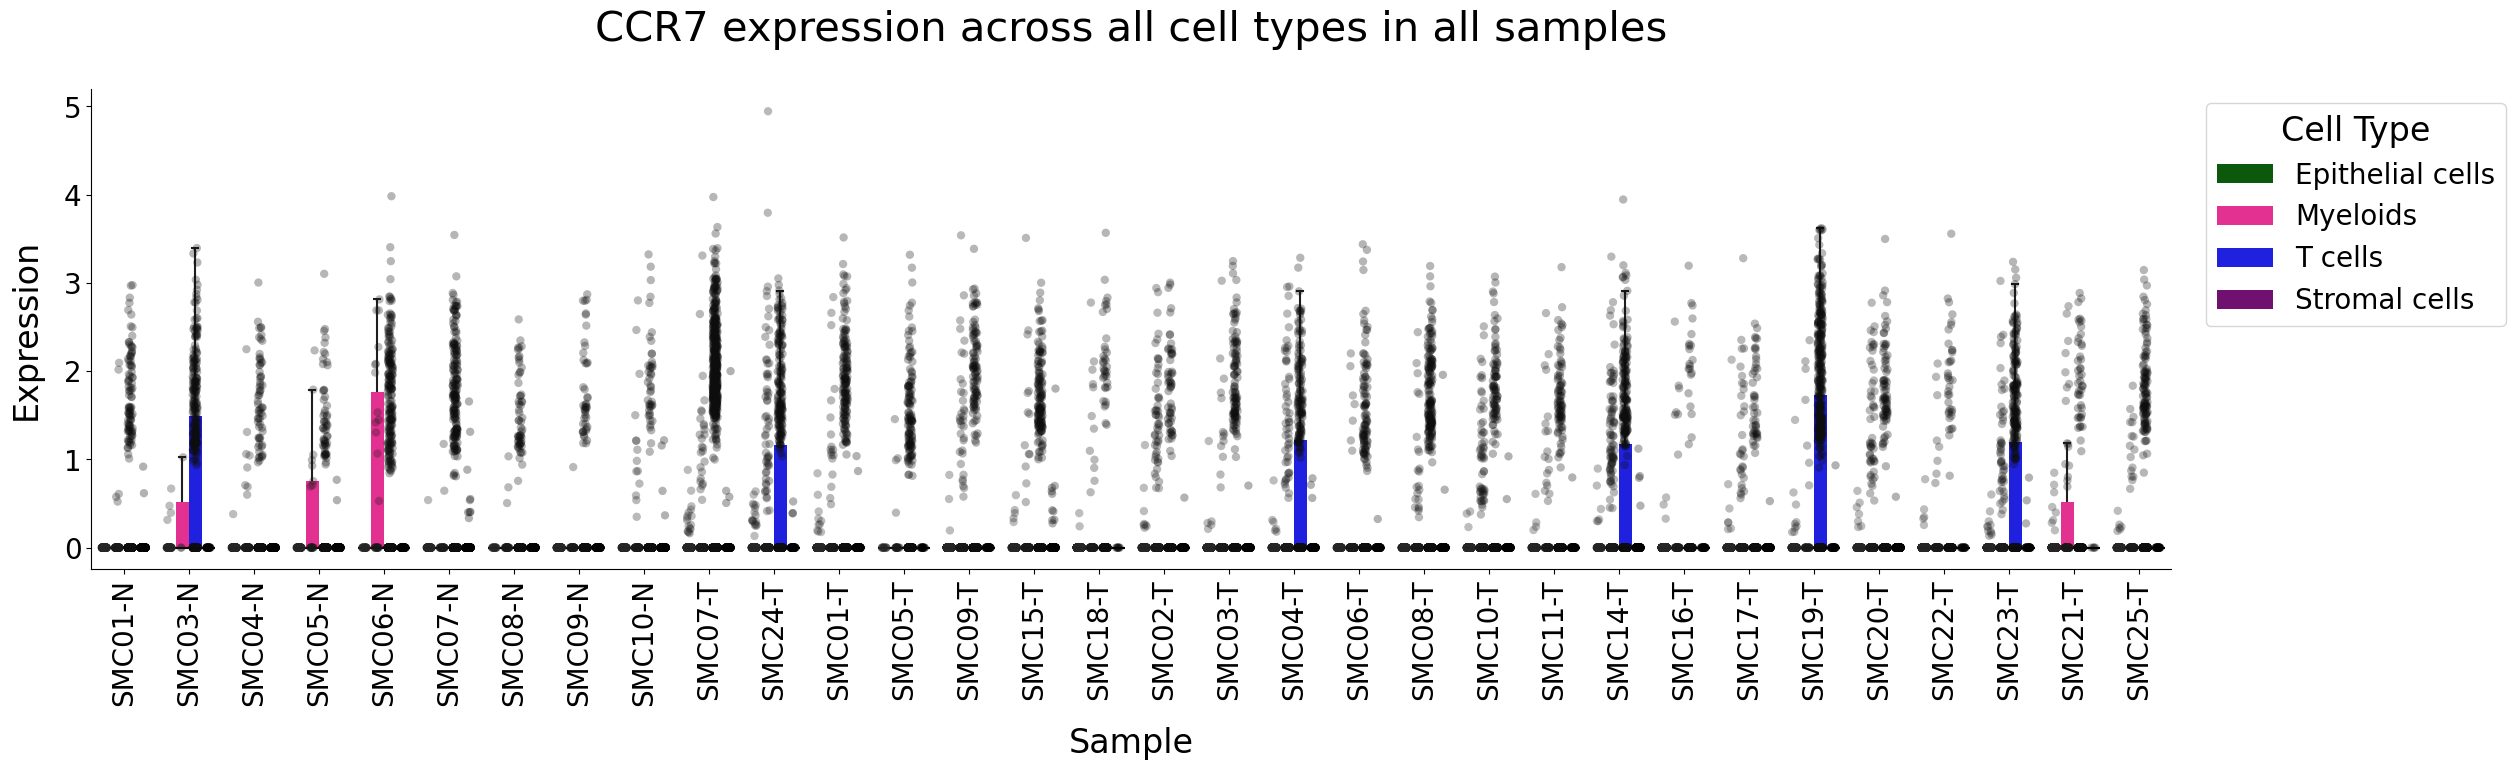

/tmp/ipykernel_24185/2747000296.py:42: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_24185/2747000296.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=20)
/tmp/ipykernel_24185/2747000296.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)


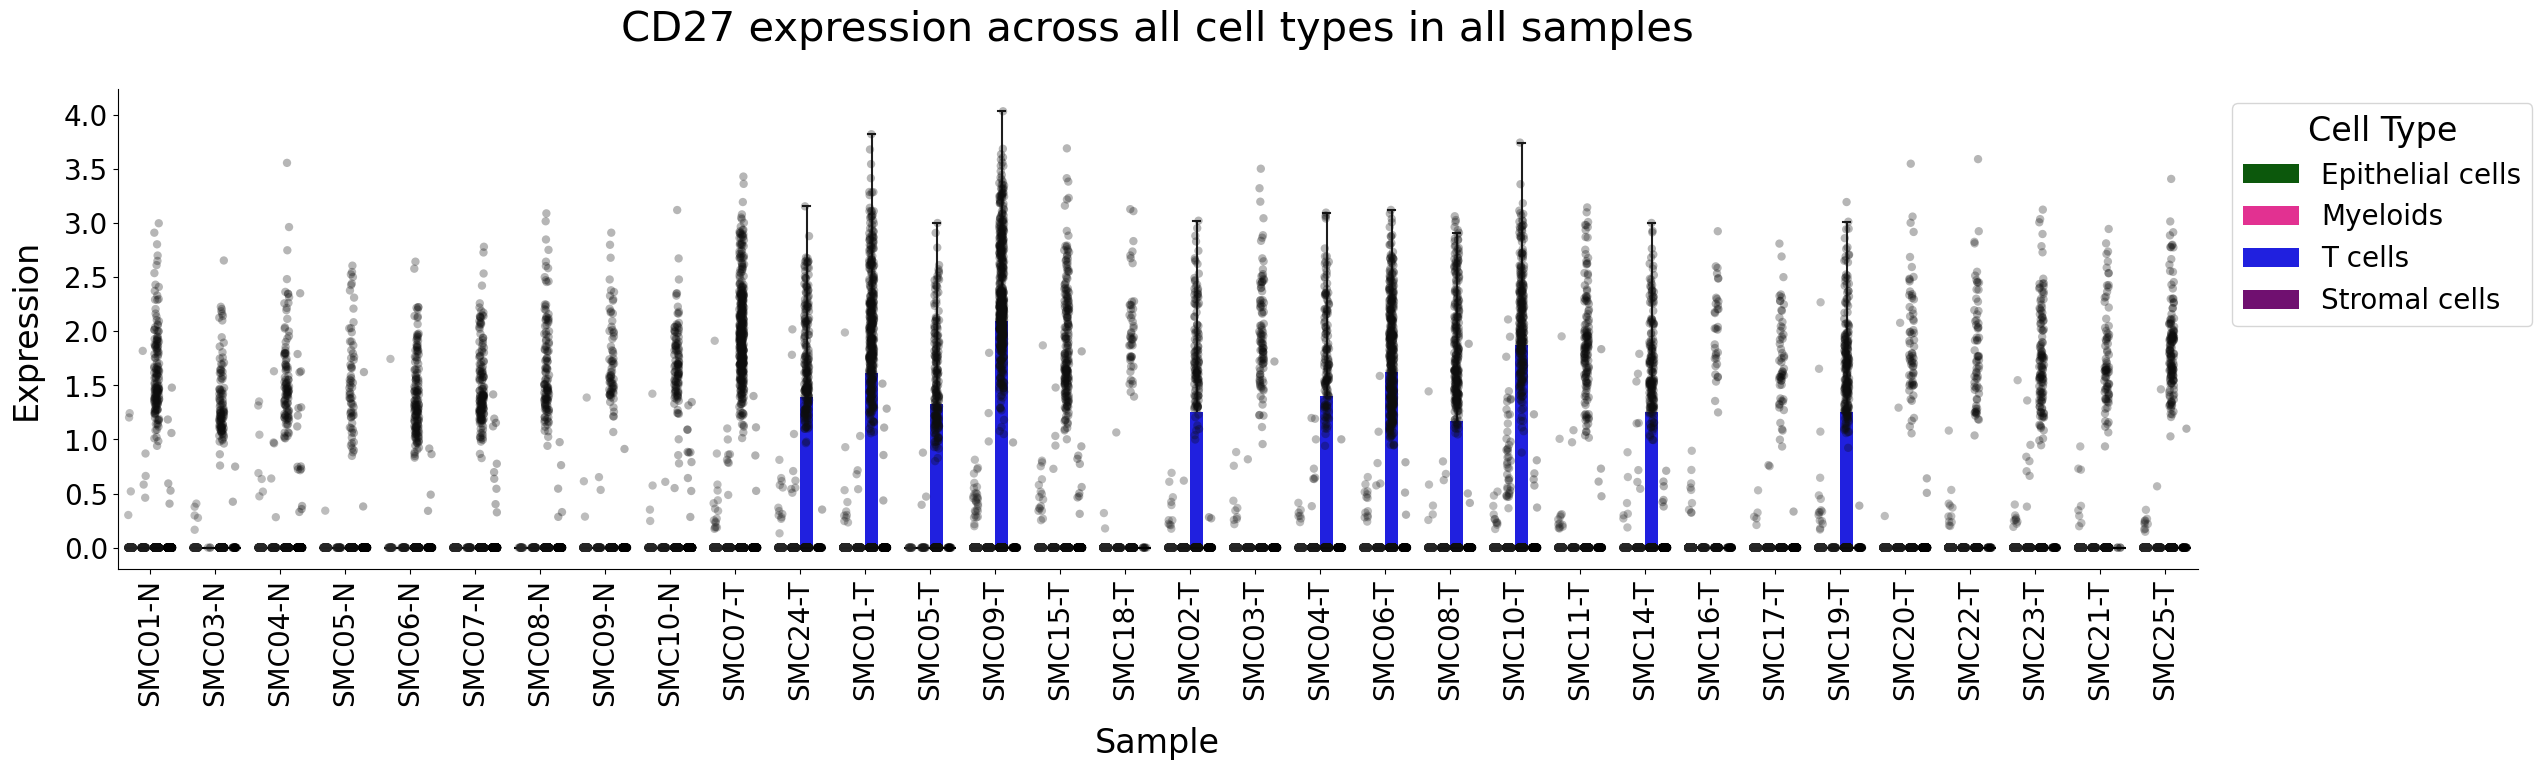

/tmp/ipykernel_24185/2747000296.py:42: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_24185/2747000296.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=20)
/tmp/ipykernel_24185/2747000296.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)


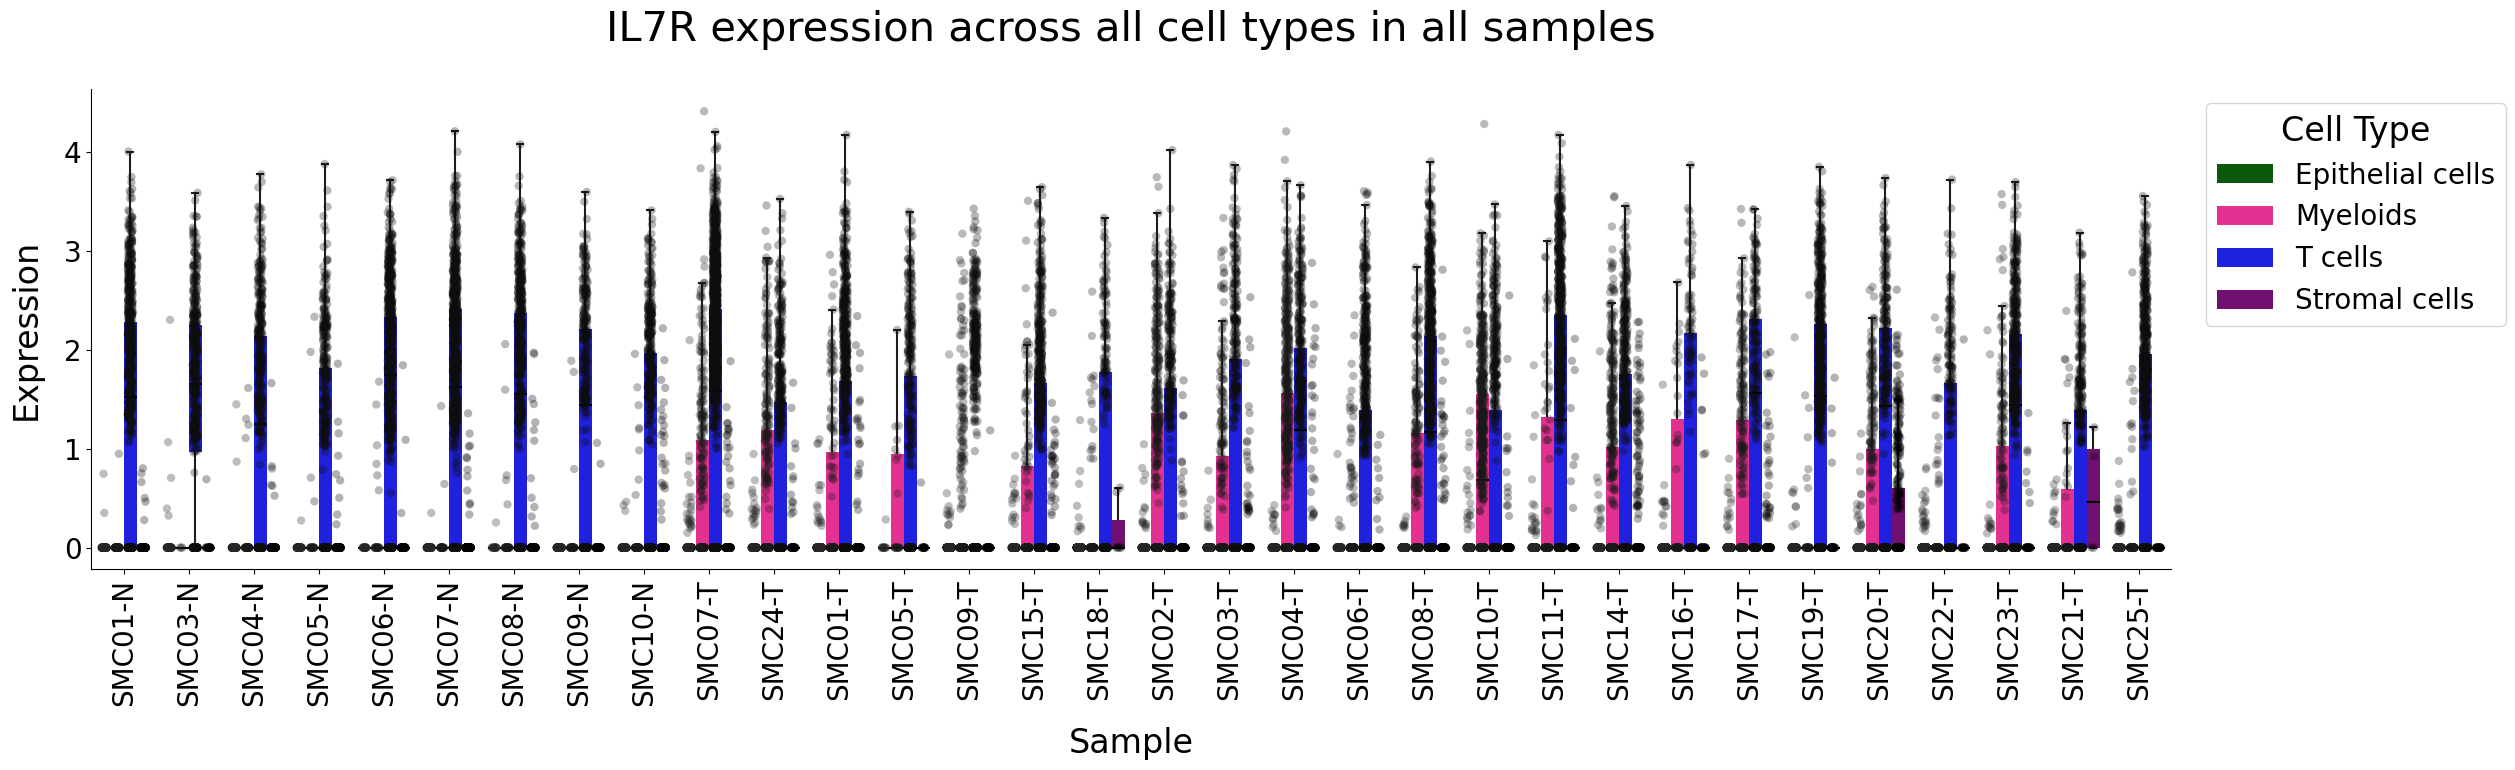

/tmp/ipykernel_24185/2747000296.py:42: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_24185/2747000296.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=20)
/tmp/ipykernel_24185/2747000296.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)


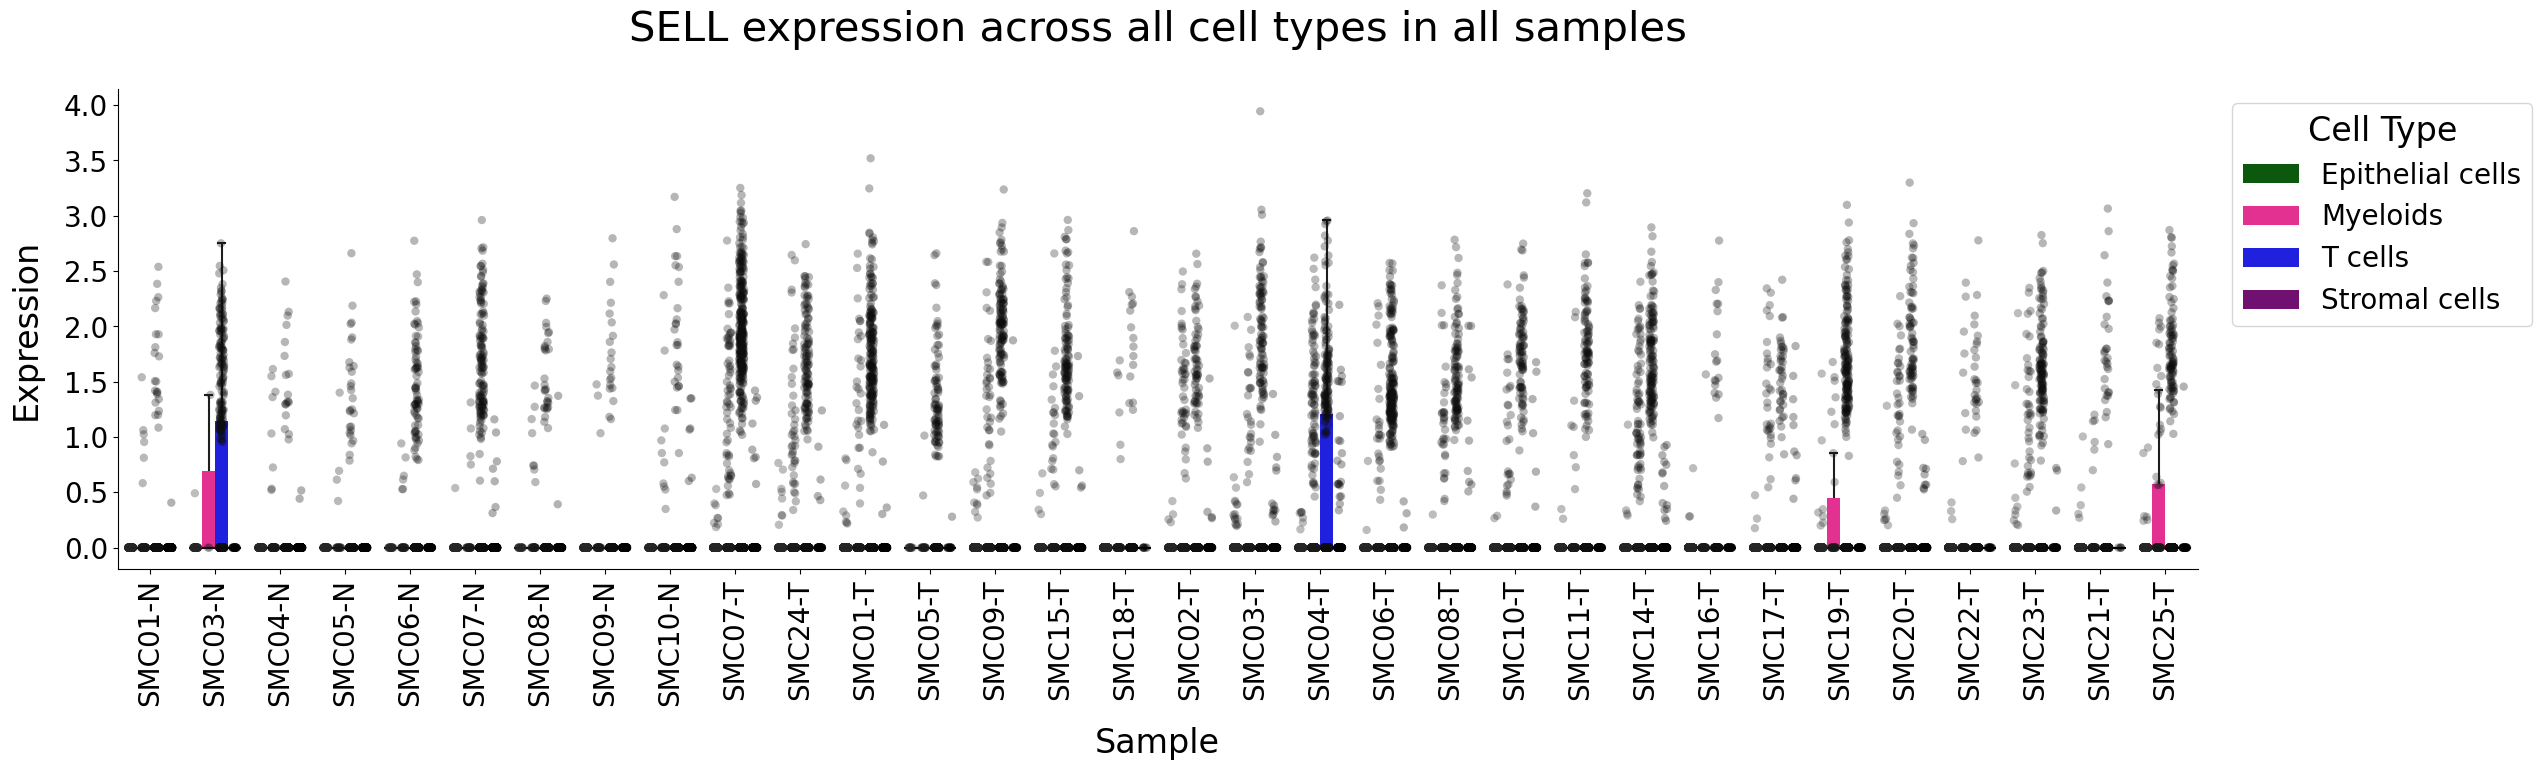

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folder to save the plots for specific marker genes group. Put the path properly below.
os.makedirs("../../pipeline_testing/markers_exp/tmemory/", exist_ok=True)

hue_order = ['Epithelial cells', 'Myeloids', 'T cells', 'Stromal cells']
custom_palette = {
    'Epithelial cells': 'darkgreen', 
    'Myeloids': 'deeppink', 
    'T cells': 'blue',
    'Stromal cells': 'purple'
}

total_data_mod = total_data.drop(columns=['stage', 'sample', 'cell_type'])
markers_mod = total_data_mod.columns
markers_mod

for markers in markers_mod:
    plt.close('all') # Clear memory from previous iteration
    fig = plt.figure(figsize=(26, 8)) 

    ax = fig.add_axes([0.05, 0.25, 0.80, 0.60])

    df1 = total_data.loc[:, [markers, 'stage', 'sample', 'cell_type']]
    sns.boxplot(
        data=df1, 
        x='sample', 
        y=markers, 
        hue='cell_type', 
        hue_order=hue_order, 
        palette=custom_palette,
        width=0.8,          
        fliersize=0, 
        boxprops={'edgecolor': 'none'}, 
        medianprops={'color': 'black', 'linewidth': 1.5},
        linewidth=1.5,
        ax=ax
    )

    sns.stripplot(
        data=df1, 
        x='sample', 
        y=markers, 
        hue='cell_type', 
        hue_order=hue_order, 
        dodge=True,          
        color='black', 
        jitter=0.15,        
        alpha=0.3, 
        size=6.0,
        ax=ax,
        legend=False 
    )
    ax.set_title(f'{markers} expression across all cell types in all samples', 
                 fontsize=30, pad=35)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)
    ax.set_xlabel('Sample', fontsize=24, labelpad=15)
    ax.set_ylabel('Expression', fontsize=24, labelpad=15)
    ax.set_xlim(-0.5, len(df1['sample'].unique()) - 0.5)
    ax.legend(
        title='Cell Type', 
        bbox_to_anchor=(1.01, 1), 
        loc='upper left',     
        frameon=True,      
        prop={'size': 20}, 
        title_fontsize=24,
        markerscale=1.0
    )
    leg = ax.get_legend()
    if leg:
        for patch in leg.get_patches():
            patch.set_linewidth(0)
    sns.despine(ax=ax)

    # put the folder path where the plots will be saved. The folder has already been generated before. (Line no - 5)
    plt.savefig(f"../../pipeline_testing/markers_exp/tmemory/{markers}_Expression_Plot.pdf", dpi=300,bbox_inches='tight')
    plt.show()